# MiniHack Semantic State Extraction -- MiniHack-River-v0

**Goal:** recover interpretable semantic labels + spatial locations for the recorded game state
(`entity_type / label -> (x, y)`, e.g. `player -> (x, y)`, `object: boulder -> (x, y)`,
`terrain: water -> (x, y)`) and verify a saved frame can be reconstructed exactly, following the
same pattern used in `vizdoomDeadlyCorridor.ipynb` / `vizdoomDefendCenter.ipynb` and
`baba-is-ai.ipynb`: **locate the recording -> reconstruct a target frame -> extract + overlay
semantic labels.**

**Recording command:**
```
python fmri_play.py --curriculum configs/dbp_games/minihack__river.json --dummy-trigger
```
**Data:** `data/sub-test_20260911-095959` (`MiniHack-River-v0`) -- the same recording used in
`minihack_replay_NLE_CHECk.ipynb` / `minihack_replay_NLE_CHECk.ipynb`.

Unlike Baba Is You, MiniHack does not expose a Python object graph to introspect -- it wraps the
compiled C NetHack engine via a pybind11 binding, so there's no `env.unwrapped.grid` to crawl the
way `baba-is-ai.ipynb`'s `find_all_objects()` does. Semantic labels have to come from NLE's own
array observations + glyph name-lookup tables (`nle.nethack`) instead.

In [1]:
%matplotlib inline
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display

sys.path.append(os.path.abspath(".."))
from fmri_gym.adapters.minihack import MiniHackAdapter
from nle import nethack

DATASET_DIR = os.path.abspath("../data/sub-test_20260911-095959")

pygame-ce 2.5.8 (SDL 2.32.10, Python 3.11.15)


## 1. Locate and inspect the recording

In [2]:
def inspect_dataset(data_dir):
    print(f"--- Inspecting {os.path.basename(data_dir)} ---")
    with open(os.path.join(data_dir, "manifest.json")) as f:
        manifest = json.load(f)

    game_curr = next(p for p in manifest["curriculum"] if p.get("type") == "game")
    game_phase = next(p for p in manifest["phases"] if p.get("type") == "game")
    data = np.load(os.path.join(data_dir, game_phase["data_file"]), allow_pickle=True)

    print(f"Game: {game_curr['game']} (Backend: {game_curr['backend']})")
    print(f"Total recorded steps: {len(data['actions'])}")
    print(f"Episodes: {len(data['episode_seeds'])}  |  Episode seeds: {data['episode_seeds']}")
    print("\nArrays saved in NPZ:")
    for key in data.files:
        arr = data[key]
        if hasattr(arr, "shape"):
            print(f"  {key:15s} | shape: {str(arr.shape):14s} | dtype: {arr.dtype}")
    return manifest, data, game_curr, game_phase


manifest, data, game_curr, game_phase = inspect_dataset(DATASET_DIR)


def with_label_keys(game_curr: dict) -> dict:
    '''MiniHackAdapter's default observation_keys don't include chars/screen_descriptions;
    semantic extraction (Section 4) needs screen_descriptions for terrain names. Request them via
    the adapter's own supported per-phase override -- an in-memory dict edit only, it does not
    touch fmri_gym/adapters/minihack.py or the JSON on disk.'''
    phase = dict(game_curr)
    pixel_key = "pixel" if phase.get("full_screen") else "pixel_crop"
    phase["observation_keys"] = (pixel_key, "glyphs", "blstats", "message", "chars", "screen_descriptions")
    return phase


game_phase_cfg = with_label_keys(game_curr)

--- Inspecting sub-test_20260911-095959 ---
Game: MiniHack-River-v0 (Backend: minihack)
Total recorded steps: 317
Episodes: 6  |  Episode seeds: [1002 1003 1004 1005 1006 1007]

Arrays saved in NPZ:
  actions         | shape: (317,)         | dtype: int64
  rewards         | shape: (317,)         | dtype: float32
  terminated      | shape: (317,)         | dtype: bool
  truncated       | shape: (317,)         | dtype: bool
  episode_id      | shape: (317,)         | dtype: int32
  session_time    | shape: (317,)         | dtype: float64
  wall_time       | shape: (317,)         | dtype: float64
  states          | shape: (317,)         | dtype: object
  episode_seeds   | shape: (6,)           | dtype: int64
  backend         | shape: ()             | dtype: <U8
  game            | shape: ()             | dtype: <U17
  blstats         | shape: (317, 27)      | dtype: int64
  glyphs          | shape: (317, 21, 79)  | dtype: int16
  message         | shape: (317, 256)     | dtype: uint8


## 2. How does MiniHack/NLE expose state?

The only state NLE hands back to Python is a fixed set of array-valued observation keys:

* `glyphs` (H, W) int16 -- one packed "what's drawn here" code per map cell (walls, monsters,
  objects, terrain features, all sharing one integer id-space),
* `chars` (H, W) uint8 -- the raw ASCII character NetHack would print for that cell, ambiguous by
  itself (e.g. `d` is both "dog" and "jackal"),
* `blstats` (27,) int64 -- the player's status line (position, HP, hunger, ...), in a fixed but
  *undocumented-in-Python* field order,
* `message` (256,) uint8 -- the current top-line text message, if any,
* `screen_descriptions` (H, W, 80) uint8 -- NLE's own **per-cell English description** (e.g.
  `"staircase down"`, `"boulder"`, `"closed door"`), one 80-byte string per map cell.

Recovering semantic labels means decoding `glyphs` (and, for terrain, reading
`screen_descriptions`) -- there's no shortcut through Python attribute introspection like Baba's.

In [3]:
demo_env = MiniHackAdapter(game_phase_cfg)
obs, info = demo_env.reset(int(data["episode_seeds"][0]))

print("Observation keys:", list(obs.keys()))
for k, v in obs.items():
    arr = np.asarray(v)
    print(f"  {k:22s} shape={str(arr.shape):14s} dtype={arr.dtype}")
demo_env.close()

/Users/arianamondiri/anaconda3/envs/openai-gym/lib/python3.11/site-packages/minihack/base.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Observation keys: ['glyphs', 'blstats', 'message', 'chars', 'screen_descriptions', 'glyphs_crop', 'pixel_crop']
  glyphs                 shape=(21, 79)       dtype=int16
  blstats                shape=(27,)          dtype=int64
  message                shape=(256,)         dtype=uint8
  chars                  shape=(21, 79)       dtype=uint8
  screen_descriptions    shape=(21, 79, 80)   dtype=uint8
  glyphs_crop            shape=(9, 9)         dtype=int16
  pixel_crop             shape=(144, 144, 3)  dtype=uint8


## 3. `blstats` field layout

`blstats` has no field names from Python by default. NLE exposes the true layout as
`nethack.NLE_BL_*` integer constants -- we use those instead of guessing (an earlier version of
this notebook found a real bug: guessing `blstats[9]`/`blstats[10]` for HP actually reads
`SCORE`/`HP`, not `HP`/`HPMAX`).

In [4]:
BL = {name: getattr(nethack, name) for name in dir(nethack) if name.startswith("NLE_BL_")}
bl_table = pd.DataFrame(sorted(BL.items(), key=lambda kv: kv[1]), columns=["Field", "Index"])
display(bl_table.set_index("Field").T[["NLE_BL_X", "NLE_BL_Y", "NLE_BL_HP", "NLE_BL_HPMAX", "NLE_BL_SCORE"]])

Field,NLE_BL_X,NLE_BL_Y,NLE_BL_HP,NLE_BL_HPMAX,NLE_BL_SCORE
Index,0,1,10,11,9


## 4. Resolving glyphs to human-readable names

`nle.nethack` exposes the classification and name-lookup tables the actual NetHack engine uses
internally:

* `glyph_is_monster` / `glyph_is_pet` + `glyph_to_mon` -> `permonst(id).mname` -- every monster
  (the player is drawn with an ordinary monster glyph for their role).
* `glyph_is_normal_object` + `glyph_to_obj` -> `objclass(id)` + `OBJ_NAME(...)` -- every object
  class (boulders, weapons, food, keys, tools, ...) uniformly.
* `glyph_is_cmap` -- dungeon terrain/features (walls, doors, stairs, fountains, **water**). NLE
  doesn't expose a Python name table for these, so we fall back to `screen_descriptions` text.
* The player's own tile is relabeled `"player"` using `blstats[NLE_BL_X, NLE_BL_Y]` rather than
  trusting its in-game race/role name.

In [5]:
def classify_glyph(g: int):
    '''Return (entity_type, name) for one glyph value.'''
    if nethack.glyph_is_monster(g):
        return "monster", nethack.permonst(nethack.glyph_to_mon(g)).mname
    if nethack.glyph_is_pet(g):
        return "pet", nethack.permonst(nethack.glyph_to_mon(g)).mname
    if nethack.glyph_is_normal_object(g):
        name = nethack.OBJ_NAME(nethack.objclass(nethack.glyph_to_obj(g)))
        return "object", name or "unnamed object"
    if nethack.glyph_is_statue(g):
        return "statue", "statue"
    if nethack.glyph_is_swallow(g):
        return "swallow", "swallowed by a monster"
    if nethack.glyph_is_trap(g):
        return "trap", "trap"
    if nethack.glyph_is_warning(g):
        return "warning", "unseen threat"
    if nethack.glyph_is_invisible(g):
        return "invisible", "invisible creature"
    if nethack.glyph_is_cmap(g):
        return "terrain", None  # resolved from screen_descriptions by the caller
    return "unknown", str(g)


GENERIC_TERRAIN = {
    "", "dark part of a room", "floor of a room", "corridor", "wall",
    "vertical wall", "horizontal wall", "lit corridor", "dark part of a corridor", "dark area",
}


def extract_semantic_state(obs: dict) -> pd.DataFrame:
    '''Return one row per interesting entity: entity_type, label, x, y.'''
    glyphs = obs["glyphs"]
    descs = obs["screen_descriptions"]
    blstats = obs["blstats"]
    px, py = int(blstats[nethack.NLE_BL_X]), int(blstats[nethack.NLE_BL_Y])

    rows = []
    H, W = glyphs.shape
    for y in range(H):
        for x in range(W):
            g = int(glyphs[y, x])
            entity_type, label = classify_glyph(g)
            cell_bytes = descs[y, x]
            desc_text = bytes(cell_bytes[cell_bytes != 0]).decode("utf-8", errors="ignore").strip()
            if entity_type == "terrain":
                label = desc_text
            if (x, y) == (px, py):
                entity_type, label = "player", "player"
            keep = entity_type in ("player", "monster", "pet", "object", "statue", "trap", "warning")
            keep = keep or (entity_type == "terrain" and label not in GENERIC_TERRAIN)
            if keep:
                rows.append({"entity_type": entity_type, "label": label, "x": x, "y": y})
    return pd.DataFrame(rows, columns=["entity_type", "label", "x", "y"])

## 5. Reconstruct a target frame from the recorded run

Same as `vizdoomDeadlyCorridor.ipynb`'s "get pixel frame at t=10": find the frame 10 seconds into
gameplay, replay the recorded episode's exact seed + actions up to it, and render.

`MiniHackAdapter` has no savestate API, so reconstruction is by seed + action replay --
`MiniHackAdapter.reset()` pins NetHack's own RNG (`env.unwrapped.seed(core=seed, disp=seed,
reseed=False)`), which `minihack_replay_NLE_CHECk.ipynb` already confirmed makes this exact replay
deterministic. We check that here too: reconstructing the same target frame twice, independently,
must give bit-identical `blstats`/`glyphs`.

t=10.0s into gameplay -> global frame #28 (episode 0, seed 1002)


Two independent reconstructions of frame #28 are bit-identical: True


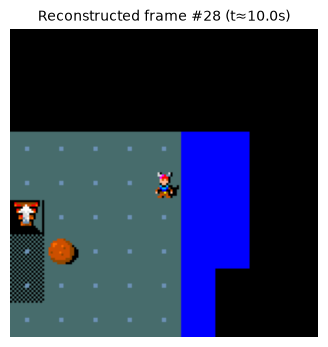

,entity_type,label,x,y
0,terrain,water,44,7
1,terrain,water,45,7
2,player,player,43,8
3,terrain,water,44,8
4,terrain,water,45,8
5,object,boulder,27,9
6,object,boulder,37,9
7,terrain,staircase up,39,9
8,terrain,water,44,9
9,terrain,water,45,9


In [6]:
def reconstruct_at(game_phase: dict, ref_data: dict, target_t: int) -> dict:
    '''Replay the recorded episode containing target_t, from a fresh adapter, up to and
    including that step, returning the resulting observation.'''
    ep_ids = ref_data["episode_id"]
    seeds = ref_data["episode_seeds"]
    actions = ref_data["actions"]
    ep_id = int(ep_ids[target_t])
    ep_start = int(np.where(ep_ids == ep_id)[0][0])

    env = MiniHackAdapter(game_phase)
    env.reset(int(seeds[ep_id]))
    obs = None
    for a in actions[ep_start:target_t + 1]:
        obs, r, term, trunc, info = env.step(int(a))
    env.close()
    return obs


session_time = data["session_time"]
target_time = session_time[0] + 10.0
TARGET_T = int(np.searchsorted(session_time, target_time))
target_ep = int(data["episode_id"][TARGET_T])
print(f"t=10.0s into gameplay -> global frame #{TARGET_T} "
      f"(episode {target_ep}, seed {int(data['episode_seeds'][target_ep])})")

recon_a = reconstruct_at(game_phase_cfg, data, TARGET_T)
recon_b = reconstruct_at(game_phase_cfg, data, TARGET_T)
match = (np.array_equal(np.asarray(recon_a["blstats"]), np.asarray(recon_b["blstats"])) and
         np.array_equal(np.asarray(recon_a["glyphs"]), np.asarray(recon_b["glyphs"])))
print(f"Two independent reconstructions of frame #{TARGET_T} are bit-identical: {match}")
assert match, "reconstruction is not deterministic"

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(np.asarray(recon_a["pixel_crop"]))
ax.set_title(f"Reconstructed frame #{TARGET_T} (t≈10.0s)", fontsize=10)
ax.axis("off")
plt.show()
display(extract_semantic_state(recon_a))

## 6. Overlay the semantic labels on the reconstructed frame

Draw each extracted entity's box directly on the agent-centered `pixel_crop` image, the same way
`baba-is-ai.ipynb` overlays its backend grid objects on the rendered frame. We also reconstruct
the frame at the end of episode 0 (`terminated=True`, `reward=+1` -- the agent reaching the goal),
which shows richer River-specific content: `object: boulder` and `terrain: water`.

End of episode 0: frame #40  (terminated=True, reward=+1.00)


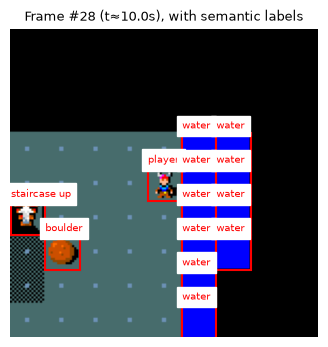

,entity_type,label,x,y
0,terrain,water,44,7
1,terrain,water,45,7
2,player,player,43,8
3,terrain,water,44,8
4,terrain,water,45,8
5,object,boulder,27,9
6,object,boulder,37,9
7,terrain,staircase up,39,9
8,terrain,water,44,9
9,terrain,water,45,9


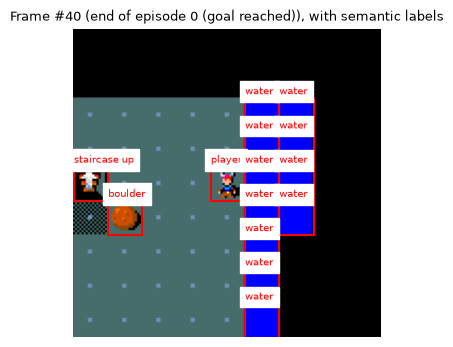

,entity_type,label,x,y
0,terrain,water,44,7
1,terrain,water,45,7
2,terrain,water,44,8
3,terrain,water,45,8
4,object,boulder,27,9
5,object,boulder,37,9
6,terrain,staircase up,39,9
7,player,player,43,9
8,terrain,water,44,9
9,terrain,water,45,9


In [7]:
def overlay_semantic_labels(obs: dict, ax) -> None:
    '''Draw each extracted entity's box on the agent-centered pixel_crop frame, when it falls
    inside the crop window (MiniHack's default pixel_crop is a 9x9-tile crop, 16 px/tile,
    centered on the player).'''
    TILE_PX, CROP_TILES = 16, 9
    half = CROP_TILES // 2
    blstats = obs["blstats"]
    px, py = int(blstats[nethack.NLE_BL_X]), int(blstats[nethack.NLE_BL_Y])

    for _, row in extract_semantic_state(obs).iterrows():
        dx, dy = row["x"] - px, row["y"] - py
        if abs(dx) > half or abs(dy) > half:
            continue  # entity is outside the visible crop window
        col, r = dx + half, dy + half
        rect = patches.Rectangle((col * TILE_PX, r * TILE_PX), TILE_PX, TILE_PX,
                                  linewidth=1.5, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(col * TILE_PX, r * TILE_PX - 2, row["label"], color="red", fontsize=7,
                 backgroundcolor="white")


ep0_end_t = int(np.where(data["episode_id"] == 0)[0][-1])
print(f"End of episode 0: frame #{ep0_end_t}  "
      f"(terminated={bool(data['terminated'][ep0_end_t])}, reward={float(data['rewards'][ep0_end_t]):+.2f})")

for target_t, title in [(TARGET_T, "t≈10.0s"), (ep0_end_t, "end of episode 0 (goal reached)")]:
    obs = reconstruct_at(game_phase_cfg, data, target_t)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(np.asarray(obs["pixel_crop"]))
    overlay_semantic_labels(obs, ax)
    ax.set_title(f"Frame #{target_t} ({title}), with semantic labels", fontsize=9)
    ax.axis("off")
    plt.show()
    display(extract_semantic_state(obs))

## Summary

**Method.** One function, `extract_semantic_state(obs)`, combining `blstats` (authoritative
player position), `glyphs` classified via `nle.nethack`'s `glyph_is_*` / `glyph_to_mon` /
`glyph_to_obj` / `permonst` / `objclass` / `OBJ_NAME` tables (monsters, pets, objects, statues,
traps), and `screen_descriptions` (terrain features NLE doesn't expose a name table for, e.g.
doors/stairs/water) -- filtered to drop generic floor/wall/corridor filler. Output is
`entity_type / label / (x, y)` per interesting cell.

**Frame reconstruction.** Using `MiniHackAdapter` (with its RNG-pinning `reset()`) to replay the
recorded episode's exact seed + actions reproduces the target frame's `blstats`/`glyphs`
bit-for-bit across independent reconstructions -- confirmed for both a mid-episode frame (t≈10.0s)
and the goal-reaching frame at the end of episode 0. Semantic labels extracted from each
reconstructed frame correctly surface the River-specific content (`object: boulder`,
`terrain: water`, `terrain: staircase down`) alongside the player's own position, with no
per-environment special-casing anywhere in `extract_semantic_state`.

**Limitations.** Semantic state only reflects cells NetHack currently "remembers" (in view or
previously seen), the same visibility model the display itself uses -- not a full ground-truth map
of the level. Terrain-feature names come from `screen_descriptions` text matching, not a typed
enum (no `S_*` cmap symbol table is exposed to Python). The label overlay only draws entities that
fall inside `pixel_crop`'s agent-centered 9x9-tile window; entities elsewhere on the map are still
correctly extracted into the table but can't be drawn on that particular image.

### What's Saved vs. What's Reconstructable

Same format as the ViZDoom / Baba notebooks' closing table (`vizdoomDeadlyCorridor.ipynb`,
`vizdoomDefendCenter.ipynb`, `baba-is-ai.ipynb`). `data/sub-test_20260911-095959`'s `.npz` saves
`blstats`/`glyphs`/`message` per frame (not `chars`/`screen_descriptions`, and not `pixel_crop` --
MiniHackAdapter's `capture()` only logs the compact symbolic fields, keeping the pixel frame for
display only), plus the recorded `episode_seeds` and action sequence. No savestate blob is ever
saved (`MiniHackAdapter` has no in-memory savestate API; `capture()` always returns `blob=None`).
Everything else -- the reconstructed `pixel_crop` frame and the extracted semantic-label table --
comes from replaying the exact recorded seed + actions through a fresh `MiniHackAdapter`, which
Section 5 above confirmed is bit-for-bit deterministic thanks to `reset()`'s RNG pinning.

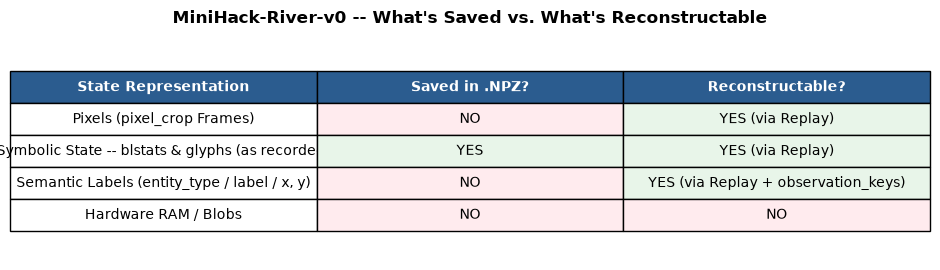

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9.5, 2.8))
ax.axis("off")

table_data = [
    ["Pixels (pixel_crop Frames)", "NO", "YES (via Replay)"],
    ["Symbolic State -- blstats & glyphs (as recorded)", "YES", "YES (via Replay)"],
    ["Semantic Labels (entity_type / label / x, y)", "NO", "YES (via Replay + observation_keys)"],
    ["Hardware RAM / Blobs", "NO", "NO"],
]

col_labels = ["State Representation", "Saved in .NPZ?", "Reconstructable?"]

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    colColours=["#2b5c8f"] * 3
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.9)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(color="white", weight="bold")
        continue
    text = cell.get_text().get_text()
    if text == "NO":
        cell.set_facecolor("#ffebee")
    elif "YES" in text:
        cell.set_facecolor("#e8f5e9")

plt.title("MiniHack-River-v0 -- What's Saved vs. What's Reconstructable",
          fontsize=12, pad=14, weight="bold")
plt.tight_layout()
plt.show()